In [89]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import xarray as xr
import h5py
from tqdm import tqdm
import time
import sys
sys.path.append("..")
sys.path.append("../development")
from RPLB_acc_NoSTC import RPLB_acc_NoSTC
from RPLB_acc_diffraction import RPLB_acc_diffraction
from RPLB_acc_diffraction_alsointensity import RPLB_acc_diffraction_alsointensity

In [101]:
# initialize constants (SI units)
c = 2.99792458e8 #speed of light
m_e = 9.10938356e-31
q_e = 1.60217662e-19
e_0 = 8.85418782e-12
# set pure spectral properties
lambda_0 = 800e-9  # central wavelength
omega_0 = 2*np.pi*c/lambda_0
k_0 = omega_0/c
tau_0 = 10e-15  # FL pulse duration 1/e2 intensity half-width (same def as beam waist)
a = 125/k_0
w_0 = np.sqrt(2)*np.sqrt(np.sqrt(1+(a*k_0)**2)-1)/k_0
print(w_0)
print(np.sqrt(2*a/k_0))
# calculate Rayleigh range
z_R = np.pi*w_0**2/lambda_0
# beam power
P = 6e12
# spectral phase
GDD = 0.0*(1e-15)**2
TOD = 0.0*(1e-15)**3
# intial electron velocity
beta_0 = 0
# set tuning parameters
t_0 = -10*tau_0
z_0 = 0.0
Psi_0 = 1.0*np.pi

axicon = 0.0
curv = 0.0
spher = 0.0
spher2 = 0.0

PM_type = 0

PM = np.zeros(shape=(9))
PM[0] = Psi_0
PM[1] = axicon
PM[2] = curv
PM[3] = spher
PM[4] = spher2

SP = np.array([1.0])

PF = np.zeros(shape=(9))

2.0051319796881284e-06
2.0131684841794813e-06


In [102]:
start = time.time()
time1, z1, beta1, KE1 = RPLB_acc_NoSTC(lambda_0, tau_0, w_0, P, Psi_0, GDD, t_0, z_0, beta_0)
middle = time.time()
time2, z2, beta2, KE2 = RPLB_acc_diffraction(lambda_0, tau_0, a, P, PM_type, PM, PF, GDD, t_0, z_0, beta_0)
middle2 = time.time()
time3, z3, beta3, KE3 = RPLB_acc_diffraction_alsointensity(lambda_0, tau_0, a, P, SP, PM_type, PM, PF, GDD, t_0, z_0, beta_0)
end = time.time()

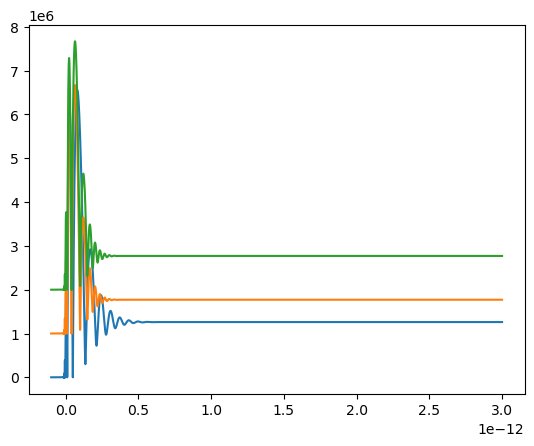

In [104]:
plt.plot(time1, KE0+0e6)
plt.plot(time2, KE2+1e6)
plt.plot(time3, KE3+2e6)
plt.show()

In [5]:
print(middle-start)
print(middle2-middle)
#print(end-middle2)

9.165892362594604
9.543989896774292


In [6]:
#SP = np.zeros(shape=(7))
#SP[0] = 1.0
#SP[1] = 0.1

#time4, z4, beta4, KE4 = RPLB_acc_NoSTC_arbitrary_alsointensity(lambda_0, tau_0, a, P, SP, PM_1, GDD, t_0, z_0, beta_0)

In [7]:
#plt.plot(time4, KE4+6e6)

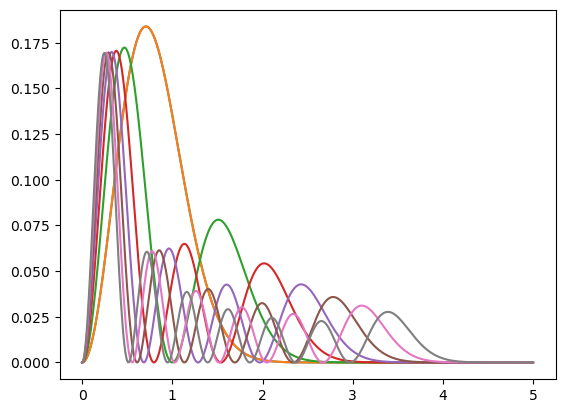

In [29]:
## old version
## arg = 2*r^2
## sum over alpha=1 generalized Laguerre polynomials
## each term normalized to sqrt(n+1)
energy = np.zeros(shape=(7))

for i in range(0,7):
    SP = np.zeros(shape=(7))
    SP[i] = 1.0

    r = np.linspace(0, 5, 501)
    scaling = r
    illum = scaling*np.exp(-scaling**2)
    spatial_profile = 1.0*SP[0] + \
                          (2 - 2*scaling**2)*SP[1]/np.sqrt(1+1) + \
                          (((2*scaling**2)**2 - 6*(2*scaling**2) + 6)/2)*SP[2]/np.sqrt(2+1) + \
                          ((-1*(2*scaling**2)**3 + 12*(2*scaling**2)**2 - 36*(2*scaling**2) + 24)/6)*SP[3]/np.sqrt(3+1) + \
                          (((2*scaling**2)**4 - 20*(2*scaling**2)**3 + 120*(2*scaling**2)**2 - 240*(2*scaling**2) + 120)/24)*SP[4]/np.sqrt(4+1) + \
                          ((-1*(2*scaling**2)**5 + 30*(2*scaling**2)**4 - 300*(2*scaling**2)**3 + 1200*(2*scaling**2)**2 - 1800*(2*scaling**2) + 720)/120)*SP[5]/np.sqrt(5+1) + \
                          (((2*scaling**2)**6 - 42*(2*scaling**2)**5 + 630*(2*scaling**2)**4 - 4200*(2*scaling**2)**3 + 12600*(2*scaling**2)**2 - 15120*(2*scaling**2) + 5040)/720)*SP[6]/np.sqrt(6+1)

    plt.plot(r, (illum*spatial_profile)**2)
    energy[i] = np.sum(scaling*(illum*spatial_profile)**2 * (scaling[1]-scaling[0]))
plt.show()

In [30]:
energy

array([0.125     , 0.125     , 0.125     , 0.125     , 0.125     ,
       0.125     , 0.12499999])

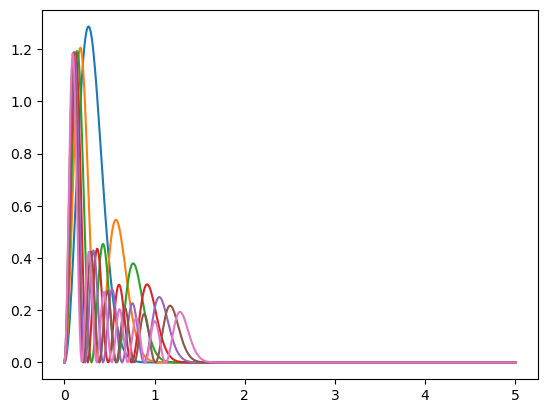

In [54]:
## new version
## N is the total number of modes for constructing the spatial profile
## argument of Laguerre Gauss = 2*(r/sqrt(N+1))^2
## sum over alpha=1 generalized Laguerre polynomials
## each term normalized to sqrt(n+1)
energy = np.zeros(shape=(7))

for i in range(0,7):
    SP = np.zeros(shape=(7))
    SP[i] = 1.0
    N = len(SP)-1

    r = np.linspace(0, 5, 501)
    scaling = r
    arg = scaling*np.sqrt(N+1)
    illum = arg*np.exp(-arg**2)
    sp_norm = np.sqrt((N+1)/np.sum(SP**2))
    spatial_profile = 1.0*SP[0] + \
                          (2 - 2*arg**2)*SP[1]/np.sqrt(1+1) + \
                          (((2*arg**2)**2 - 6*(2*arg**2) + 6)/2)*SP[2]/np.sqrt(2+1) + \
                          ((-1*(2*arg**2)**3 + 12*(2*arg**2)**2 - 36*(2*arg**2) + 24)/6)*SP[3]/np.sqrt(3+1) + \
                          (((2*arg**2)**4 - 20*(2*arg**2)**3 + 120*(2*arg**2)**2 - 240*(2*arg**2) + 120)/24)*SP[4]/np.sqrt(4+1) + \
                          ((-1*(2*arg**2)**5 + 30*(2*arg**2)**4 - 300*(2*arg**2)**3 + 1200*(2*arg**2)**2 - 1800*(2*arg**2) + 720)/120)*SP[5]/np.sqrt(5+1) + \
                          (((2*arg**2)**6 - 42*(2*arg**2)**5 + 630*(2*arg**2)**4 - 4200*(2*arg**2)**3 + 12600*(2*arg**2)**2 - 15120*(2*arg**2) + 5040)/720)*SP[6]/np.sqrt(6+1)

    plt.plot(r, (illum*spatial_profile*sp_norm)**2)
    energy[i] = np.sum(scaling*(illum*spatial_profile*sp_norm)**2 * (scaling[1]-scaling[0]))
plt.show()
print(energy)

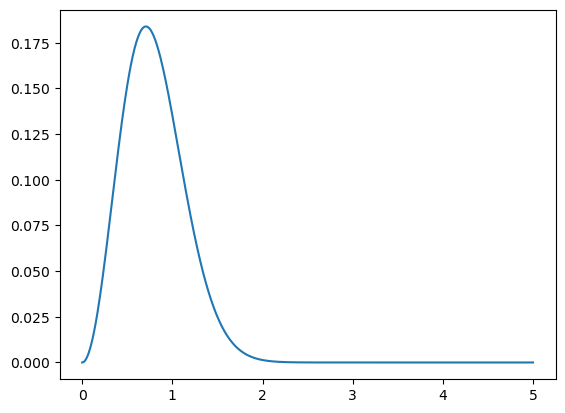

0.12500000008334128


In [100]:
# final test creating a single profile with an input SP array of variable length (up to seven)

SP = np.array([1.0])
N = np.minimum(len(SP)-1, 6)

SPn = np.append(SP, np.zeros(shape=(7-N-1)))
r = np.linspace(0, 5, 501)
scaling = r
arg = scaling*np.sqrt(N+1)
illum = arg*np.exp(-arg**2)
sp_norm = np.sqrt((N+1)/np.sum(SP**2))
spatial_profile = 1.0*SPn[0] + \
                      (2 - 2*arg**2)*SPn[1]/np.sqrt(1+1) + \
                      (((2*arg**2)**2 - 6*(2*arg**2) + 6)/2)*SPn[2]/np.sqrt(2+1) + \
                      ((-1*(2*arg**2)**3 + 12*(2*arg**2)**2 - 36*(2*arg**2) + 24)/6)*SPn[3]/np.sqrt(3+1) + \
                      (((2*arg**2)**4 - 20*(2*arg**2)**3 + 120*(2*arg**2)**2 - 240*(2*arg**2) + 120)/24)*SPn[4]/np.sqrt(4+1) + \
                      ((-1*(2*arg**2)**5 + 30*(2*arg**2)**4 - 300*(2*arg**2)**3 + 1200*(2*arg**2)**2 - 1800*(2*arg**2) + 720)/120)*SPn[5]/np.sqrt(5+1) + \
                      (((2*arg**2)**6 - 42*(2*arg**2)**5 + 630*(2*arg**2)**4 - 4200*(2*arg**2)**3 + 12600*(2*arg**2)**2 - 15120*(2*arg**2) + 5040)/720)*SPn[6]/np.sqrt(6+1)

plt.plot(r, (illum*spatial_profile*sp_norm)**2)
plt.show()
energy = np.sum(scaling*(illum*spatial_profile*sp_norm)**2 * (scaling[1]-scaling[0]))
print(energy)